In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df= pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\Groceries_dataset.csv')

In [4]:
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [5]:
print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [7]:
item_counts = df["itemDescription"].value_counts()


In [9]:
item_counts

itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64

In [12]:
# Frequently Purchased
threshold = item_counts.mean()
df["High_Demand"] = df["itemDescription"].apply(lambda x: 1 if item_counts[x] > threshold else 0)

In [11]:
threshold

np.float64(232.125748502994)

In [13]:
#label Encoder
le = LabelEncoder()
df["itemEncoded"] = le.fit_transform(df["itemDescription"])


In [14]:
le

LabelEncoder()

In [15]:
print(df.head)

<bound method NDFrame.head of        Member_number        Date        itemDescription  High_Demand  \
0               1808  21-07-2015         tropical fruit            1   
1               2552  05-01-2015             whole milk            1   
2               2300  19-09-2015              pip fruit            1   
3               1187  12-12-2015       other vegetables            1   
4               3037  01-02-2015             whole milk            1   
...              ...         ...                    ...          ...   
38760           4471  08-10-2014          sliced cheese            0   
38761           2022  23-02-2014                  candy            0   
38762           1097  16-04-2014               cake bar            0   
38763           1510  03-12-2014  fruit/vegetable juice            1   
38764           1521  26-12-2014               cat food            0   

       itemEncoded  
0              156  
1              164  
2              109  
3              102  


In [16]:
 # Features and Target
X = df[["itemEncoded"]]
y = df["High_Demand"]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Decision Tree Model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [21]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [22]:
print("Decision Tree Report:", classification_report(y_test, y_pred_dt))

Decision Tree Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1645
           1       1.00      1.00      1.00      6108

    accuracy                           1.00      7753
   macro avg       1.00      1.00      1.00      7753
weighted avg       1.00      1.00      1.00      7753



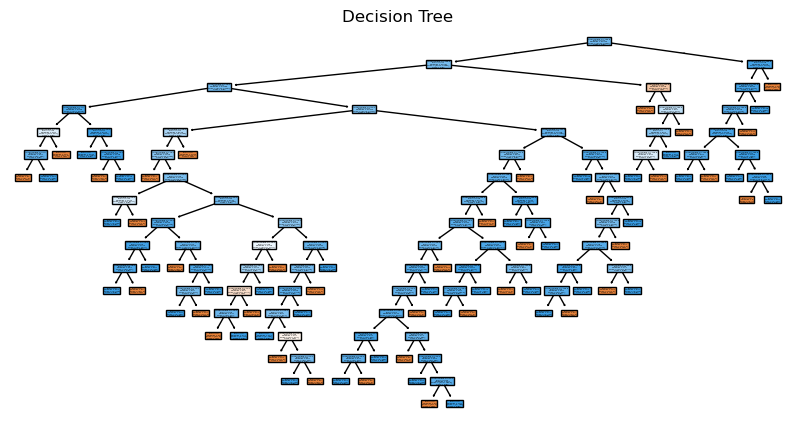

In [23]:
# Decision Tree Visualization

plt.figure(figsize=(10,5))
plot_tree(dt, filled=True, feature_names=["itemEncoded"], class_names=["Low","High"])
plt.title("Decision Tree")
plt.show()

In [24]:
# Random Forest Model

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [25]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [26]:
print("Random Forest Report:", classification_report(y_test, y_pred_rf))

Random Forest Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1645
           1       1.00      1.00      1.00      6108

    accuracy                           1.00      7753
   macro avg       1.00      1.00      1.00      7753
weighted avg       1.00      1.00      1.00      7753



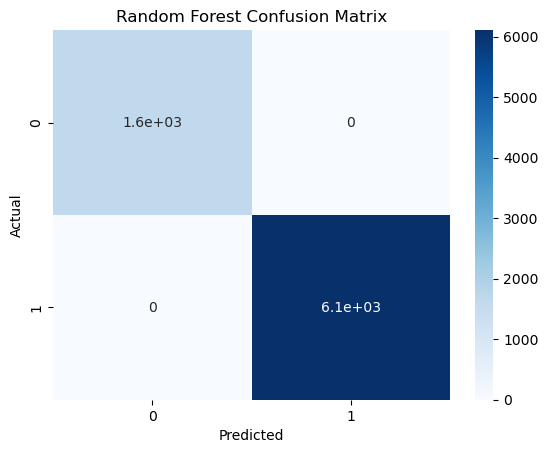

In [33]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()